# Synthetic biology with `ov.synbio` — from metabolism to enzyme to DNA

This tutorial introduces `omicverse.synbio`, a self-contained **three-layer design stack** for synthetic biology: **metabolic networks (A)**, **protein / enzyme design (B)**, and **DNA (C)**. Unlike a metabolism-only or a protein-only toolkit, the layers are wired together — the signature move is the **A↔B hinge**: predict a turnover number from an enzyme's *sequence*, push it into a genome-scale metabolic model as an enzyme-capacity constraint, and re-solve the achievable *yield*.

Everything below runs on **real data**: the `e_coli_core` genome-scale model from BiGG, the 56-residue immunoglobulin-binding **protein G B1 domain (GB1)**, and the real *E. coli* phosphofructokinase (**PfkA**) enzyme.

By the end you will understand:

- How to load a genome-scale metabolic model (GEM), run **FBA**, propose strain-design targets, and read a **production envelope**
- How the protein layer folds a sequence with **ESMFold** (and renders it in interactive 3D), embeds it with **ESM-2**, scores every point mutation with a zero-shot **ESM saturation scan** (visualised as a deep-mutational-scan heatmap), redesigns a backbone with **ProteinMPNN**, and scores thermostability **ΔΔG**
- How to **codon-optimize** a gene for a host and design **PCR primers**
- The moat — how `enzyme_kcat → ec_model → fba` turns *an enzyme edit* into *a recomputed metabolic yield*, plotted as a k_cat→yield curve

The protein layer uses a GPU automatically when one is available. Install with `pip install 'omicverse[synbio]'`.

## 0 — Setup

We only import `omicverse` — every synbio function is accessed through `ov.synbio.*`, so the notebook stays terse and the API is discoverable via tab-completion on `ov.synbio`. Plotting helpers live in the package too (`ov.synbio.plot_*`, `ov.synbio.view_structure`), so each figure is a single call.

In [1]:
import omicverse as ov

ov.plot_set()
print('omicverse', ov.__version__)

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


🔬 Starting plot initialization...
🧬 Detecting GPU devices…


✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

omicverse 2.2.1rc1


The whole module is registered under the `synthetic_biology` category. `ov.find_function` does fuzzy search across Chinese + English aliases — this is how the omicOS agent kernel discovers synbio tools.

In [2]:
ov.find_function('代谢模型')   # -> ov.synbio.load_gem

🔍 Found 4 matching function(s):


1. 📦 omicverse.synbio._gem.load_gem
   📝 加载基因组尺度代谢模型 (GEM):本地 SBML 文件或 BiGG 模型 id (如 e_coli_core / iML1515) → cobra.Model。Load a genome-scale metabolic model from an SBML path or BiGG id.
   🏷️  Aliases: load_gem, 代谢模型, 基因组尺度代谢模型, 读取GEM, read_sbml, cobra_model, genome_scale_model
   📁 Category: synthetic_biology

2. 📦 omicverse.synbio._ec.ec_model
   📝 酶约束代谢模型 (GECKO / sMOMENT):把 kcat + 酶分子量转成蛋白质量预算约束。method='gecko'(默认)约束全酶促反应组(改一个酶的 kcat 会在共享蛋白预算里重新分配,物理正确);method='pool' 只约束给定反应。Enzyme-constrained model (sMOMENT/GECKO): full-proteome or targeted.
   🏷️  Aliases: ec_model, 酶约束模型, 酶约束代谢模型, enzyme_constrained_model, GECKO, ecModel, 酶约束
   📁 Category: synthetic_biology

3. 📦 omicverse.single._metabolism.Metabolism
   📝 Single-cell metabolism inference. Wraps scMetabolism (pathway activity), Compass (constraint-based reaction flux) and scFEA (graph-neural-network module flux) behind a unified method= API; results land in adata.obsm['X_metabolism'] / adata.

<function omicverse.synbio._gem.load_gem(path_or_id: 'str', cache_dir: 'Optional[str]' = None) -> "'cobra.Model'">

## 1 — Layer A: genome-scale metabolic models

`load_gem` accepts a local SBML file or a BiGG identifier. `e_coli_core` is the classic 95-reaction core-metabolism model of *E. coli* — small enough to be instant, real enough to be meaningful. The currency of this layer is a `cobra.Model`; nothing here touches AnnData.

In [3]:
m = ov.synbio.load_gem('e_coli_core')
print(m.id, '|', len(m.reactions), 'reactions,', len(m.genes), 'genes')

INFO:cobra.io.web.load:Attempting to fetch 'e_coli_core' from the Cobrapy repository.


INFO:cobra.io.web.load:Attempting to fetch 'e_coli_core' from the BiGG Models repository.


Output()

INFO:httpx:HTTP Request: GET http://bigg.ucsd.edu/static/models/e_coli_core.xml.gz "HTTP/1.1 200 OK"


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


e_coli_core | 95 reactions, 137 genes


**Flux Balance Analysis (FBA)** maximizes the biomass reaction subject to the stoichiometric and steady-state constraints. On glucose minimal medium the model predicts a growth rate of ~0.87 h⁻¹ — the canonical answer for `e_coli_core`.

In [4]:
sol = ov.synbio.fba(m)
print('max growth =', round(sol.objective_value, 4), '/h')

max growth = 0.8739 /h


### 1.1 — Strain design and the production envelope

`strain_design` ranks engineering targets for over-producing a metabolite. Two dependency-free engines run together: **FSEOF** (Flux Scanning based on Enforced Objective Flux) finds *amplification* targets — reactions whose flux must rise as production is enforced — and a growth-coupled knockout scan finds *deletion* targets. Here we target **succinate** (`EX_succ_e`).

In [5]:
res = ov.synbio.strain_design(m, 'EX_succ_e')
print('amplify (FSEOF):', list(res.amplify['reaction'].head(5)))
res.amplify.head()

amplify (FSEOF): ['SUCCt3', 'EX_h_e', 'FRD7', 'FUM', 'PPC']


,reaction,slope,l0,l1
0,SUCCt3,1.000000,1.638417,14.745750
1,EX_h_e,0.931367,19.092127,31.287555
2,FRD7,0.905043,0.000000,10.852285
3,FUM,0.727314,3.312901,10.852285
4,PPC,0.472126,3.897654,11.108854


**Compare algorithms (side by side).** `method='fseof'` (above) is a fast, dependency-free heuristic that *ranks* over-expression targets. `method='optknock'` runs the exact bilevel **MILP** OptKnock (via the StrainDesign package) — the rigorous method for concrete *knockout designs*.

In [6]:
# same target, two strain-design algorithms — side by side
fseof  = ov.synbio.strain_design(m, 'EX_succ_e', method='fseof')
oknock = ov.synbio.strain_design(m, 'EX_succ_e', method='optknock', max_knockouts=2, time_limit=90)
print("COMPARISON — succinate over-production design")
print("  method='fseof'    (heuristic) amplify targets:", list(fseof.amplify['reaction'].head(3)))
print("  method='optknock' (exact StrainDesign MILP) knockout designs:")
print(oknock.knockout.head(3).to_string(index=False))

COMPARISON — succinate over-production design
  method='fseof'    (heuristic) amplify targets: ['SUCCt3', 'EX_h_e', 'FRD7']
  method='optknock' (exact StrainDesign MILP) knockout designs:
knockouts  n_knockouts
 [ICDHyr]            1
   [GLNS]            1
  [PIt2r]            1


The top amplification targets — **FRD7** (fumarate reductase), **FUM** (fumarase), **PPC** (PEP carboxylase) — are exactly the enzymes a metabolic engineer would over-express to push carbon toward succinate.

The **production envelope** makes the growth–production trade-off explicit: for acetate (`EX_ac_e`), the feasible growth rate shrinks as we force more product secretion — the fundamental tension every strain design must navigate.

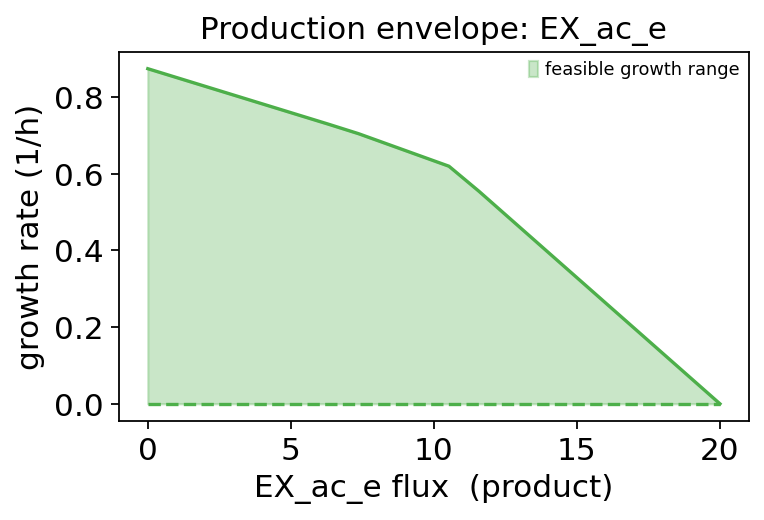

In [7]:
ov.synbio.plot_production_envelope(m, 'EX_ac_e')
None

## 2 — Layer B: protein & enzyme design (GPU)

The protein layer is built on public state-of-the-art open models — **ESM-2 / ESM-1v / ESMFold** and **ProteinMPNN**. Each function prints the device it actually used, so you can confirm the GPU is engaged. Our test protein is the 56-residue **GB1 domain** — a small, well-folded natural protein.

In [8]:
GB1 = 'MTYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDDATKTFTVTE'
len(GB1)

56

### 2.1 — ESM-2 embeddings

`protein_embed` returns a fixed-length vector per sequence (mean-pooled residue representations from ESM-2). These feed any downstream model — property regressors, clustering, function transfer.

In [9]:
X = ov.synbio.protein_embed([GB1], model='esm2_t33_650M')
X.shape          # (1, 1280)

[ov.synbio.protein_embed] model=esm2_t33_650M device=cuda (NVIDIA H100 80GB HBM3, 79 GB)


(1, 1280)

### 2.2 — Zero-shot variant effect (in-silico directed evolution)

`variant_effect` scores substitutions with an ESM language model — no labels needed. With `mutations=None` it runs a **full saturation scan** (every position × 19 alternatives): a computational deep-mutational-scan. A positive score means the model *prefers* the mutant.

In [10]:
dms = ov.synbio.variant_effect(GB1, model='esm1v')
print('scored', len(dms), 'substitutions')
dms.head()          # most-favoured substitutions first

[ov.synbio.variant_effect] model=esm1v scoring=masked-marginals device=cuda (NVIDIA H100 80GB HBM3, 79 GB)


scored 1064 substitutions


,mutation,wt,pos,mut,score
0,F30A,F,30,A,2.283173
1,V21A,V,21,A,2.167181
2,V21K,V,21,K,2.088095
3,W43V,W,43,V,2.042460
4,K13D,K,13,D,2.005156


`plot_variant_effect` renders the whole scan as a **deep-mutational-scan heatmap** (position × amino acid). Blue columns are conserved (few tolerated substitutions); red cells are substitutions the model favours. Black dots mark the wild-type residue at each position.

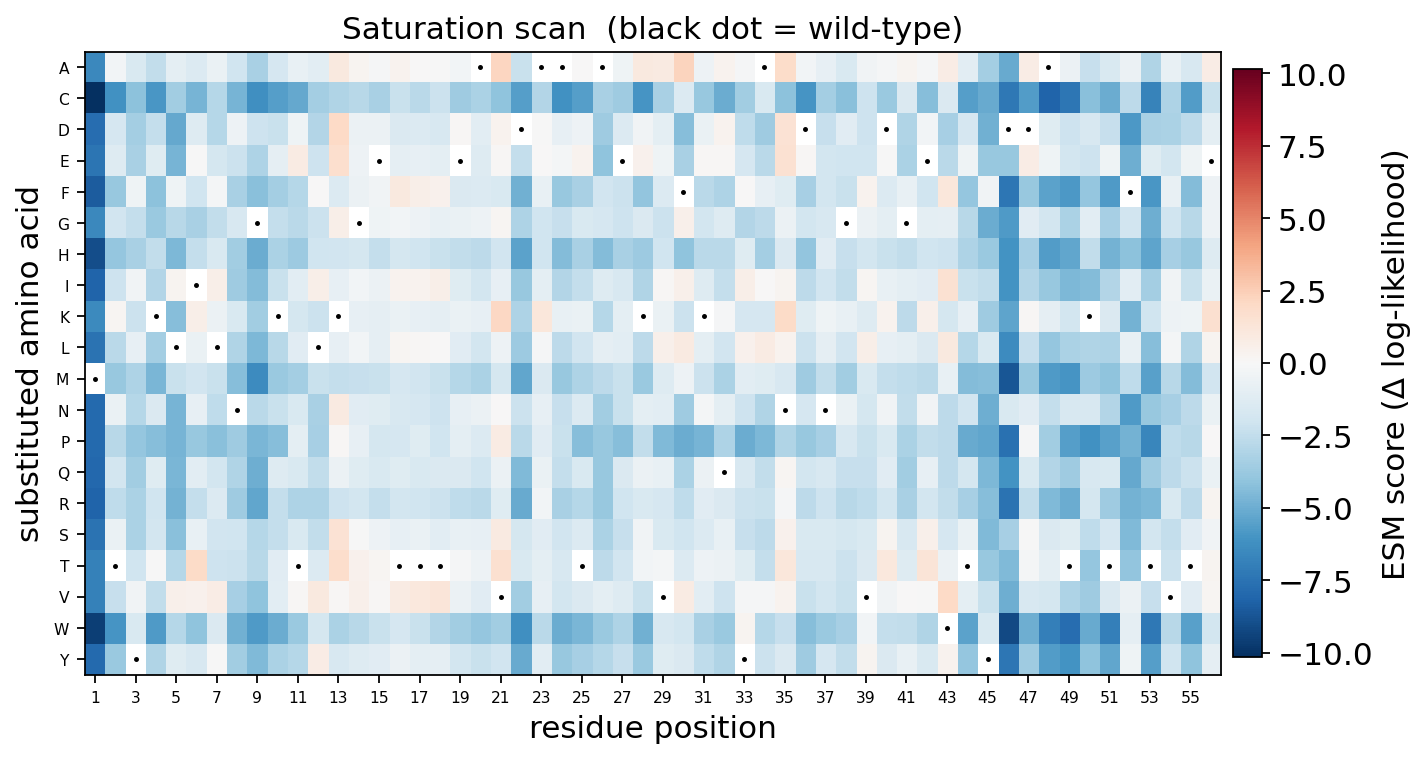

In [11]:
ov.synbio.plot_variant_effect(dms)
None

### 2.3 — Structure prediction with ESMFold

`predict_structure` folds a single sequence into 3D coordinates with ESMFold (no MSA). It requires a GPU by default. The mean **pLDDT** (0–100) reports model confidence — GB1 is a well-behaved domain and scores high.

In [12]:
pred = ov.synbio.predict_structure(GB1, out_path='gb1.pdb')
print('mean pLDDT =', round(pred.mean_plddt, 1), '| device =', pred.device)

[ov.synbio.predict_structure] device=cuda (NVIDIA H100 80GB HBM3, 79 GB) len=56


Some weights of EsmForProteinFolding were not initialized from the model checkpoint at facebook/esmfold_v1 and are newly initialized: ['esm.contact_head.regression.bias', 'esm.contact_head.regression.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[ov.synbio.predict_structure] done: mean pLDDT=89.0
mean pLDDT = 89.0 | device = cuda


`view_structure` renders it as an **interactive 3D cartoon** (py3Dmol), coloured by pLDDT confidence bands (blue = very high, orange = low). Drag to rotate; the view persists in the exported HTML docs.

In [13]:
ov.synbio.view_structure(pred)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### 2.4 — Inverse design (ProteinMPNN) and thermostability ΔΔG

Given the backbone we just folded, `inverse_design` (ProteinMPNN) samples new sequences predicted to adopt the same fold — the inverse problem of folding. A lower ProteinMPNN score is more confident; good designs beat the native sequence's score.

In [14]:
designs = ov.synbio.inverse_design('gb1.pdb', num_sequences=4)
print('native score:', round(designs[0].score, 3),
      '| best design score:', round(designs[1].score, 3))

[ov.synbio.inverse_design] method=proteinmpnn backbone=gb1.pdb device=cuda (NVIDIA H100 80GB HBM3, 79 GB) n=4


native score: 1.344 | best design score: 0.859


`stability_ddg` estimates how a point mutation changes fold stability, using the ProteinMPNN log-likelihood ΔΔG proxy (a positive value = predicted destabilizing).

In [15]:
ddg = ov.synbio.stability_ddg('gb1.pdb', mutations=['T2V', 'K4E', 'L5A'])
ddg

[ov.synbio.stability_ddg] pdb=gb1.pdb method=proteinmpnn device=cuda (NVIDIA H100 80GB HBM3, 79 GB)


,mutation,wt,pos,mut,ddg_proxy
0,L5A,L,5,A,5.038882
1,K4E,K,4,E,1.367056
2,T2V,T,2,V,1.047549


**Compare algorithms.** The default `method='proteinmpnn'` is a zero-shot log-likelihood ΔΔG *proxy* (no training labels). `method='thermompnn'` runs the real **ThermoMPNN** model (Dieckhaus 2024) — a stability head trained on the mega-scale dataset — giving calibrated ΔΔG in kcal/mol (positive = destabilising). ThermoMPNN is auto-cloned on first use.

In [16]:
cmp = ov.synbio.stability_ddg('gb1.pdb', mutations=['T2V','K4E','L5A'], method='thermompnn')
print('ThermoMPNN (real, trained) ΔΔG kcal/mol:')
cmp

[ov.synbio.stability_ddg] pdb=gb1.pdb method=thermompnn device=cuda (NVIDIA H100 80GB HBM3, 79 GB)


ThermoMPNN (real, trained) ΔΔG kcal/mol:


,mutation,wt,pos,mut,ddg
0,L5A,L,5,A,2.379662
1,K4E,K,4,E,1.627585
2,T2V,T,2,V,-0.224619


Run the **full** ThermoMPNN saturation scan and view it as a ΔΔG heatmap — the same `plot_variant_effect` helper, now on calibrated kcal/mol values. Red = destabilising, blue = stabilising; buried positions light up as intolerant columns.

[ov.synbio.stability_ddg] pdb=gb1.pdb method=thermompnn device=cuda (NVIDIA H100 80GB HBM3, 79 GB)


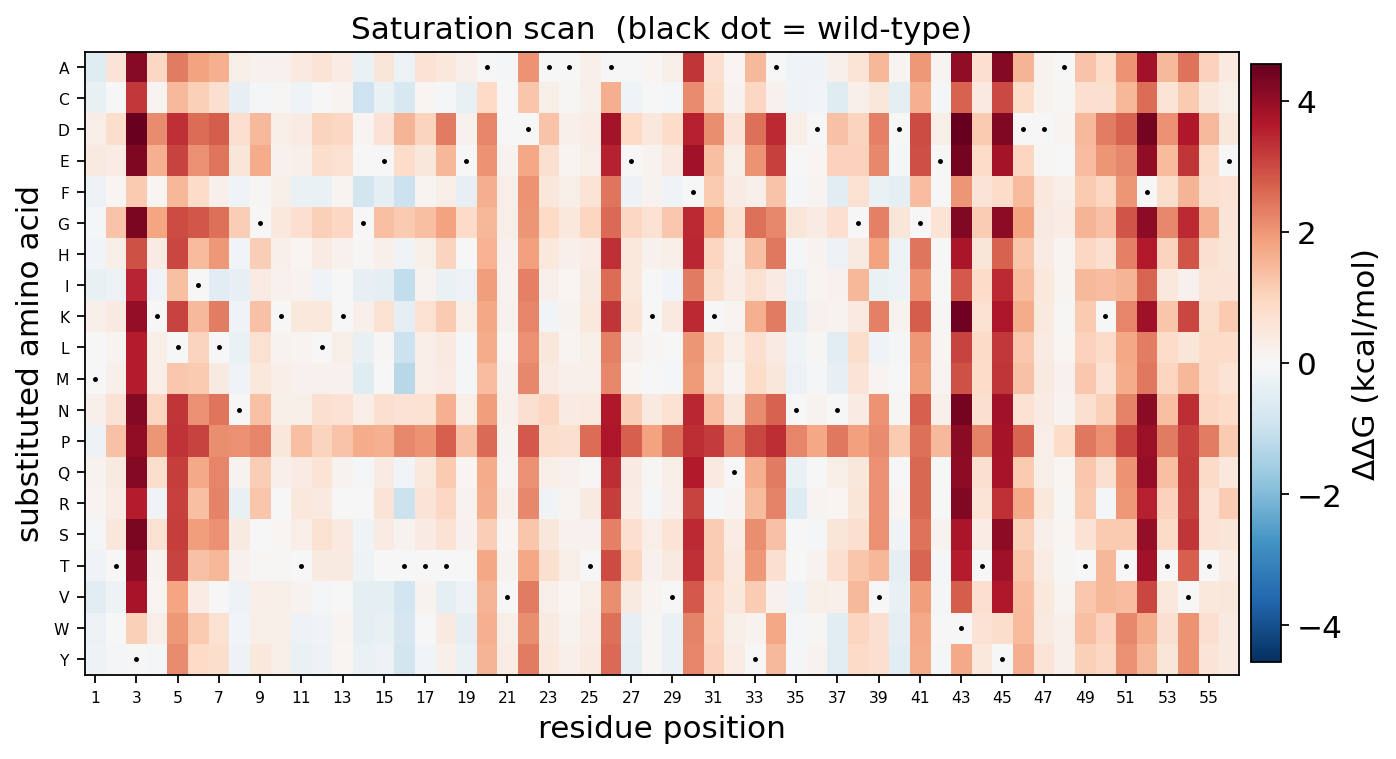

In [17]:
ssm = ov.synbio.stability_ddg('gb1.pdb', method='thermompnn')   # full saturation scan
ov.synbio.plot_variant_effect(ssm)                              # real ΔΔG landscape (kcal/mol)
None

## 3 — Layer C: DNA design

To actually build a protein you need a gene. `codon_optimize` rewrites a sequence for a host's codon usage while respecting GC bounds and removing unwanted restriction sites (DNAchisel). `design_primers` then designs validated PCR primer pairs (primer3).

CodonResult(host='e_coli', len=168, edits=36, GC=0.51, constraints_ok=True)


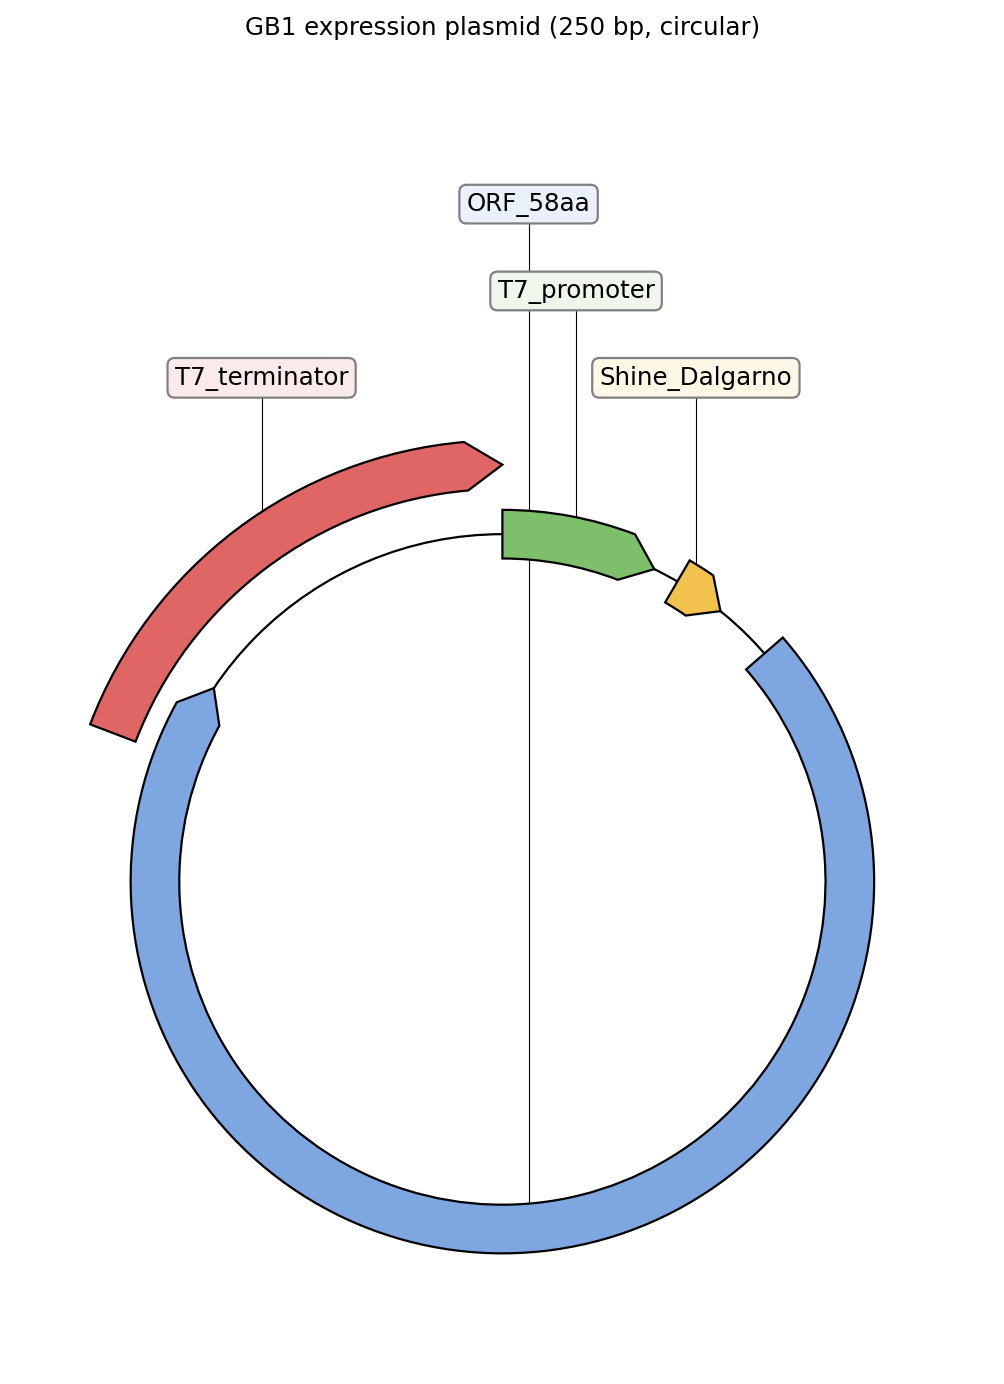

In [18]:
opt = ov.synbio.codon_optimize(GB1, host='e_coli')
print(opt)
# wrap the codon-optimised gene in a T7 expression cassette and view it as a plasmid map
cassette = ('TAATACGACTCACTATAGG' + 'AAAGGAGGACAACAT' + opt.sequence
            + 'CTAGCATAACCCCTTGGGGCCTCTAAACGGGTCTTGAGGGGTTTTTTG')
ov.synbio.view_construct(cassette, circular=True, title='GB1 expression plasmid')
None

cloning primers: PrimerPair(product=147bp, Tm=60.0/60.1, L=CGACCGCGGAAAAAGTGTTT, R=TGGTTTCGCCTTTCAGGGTT)


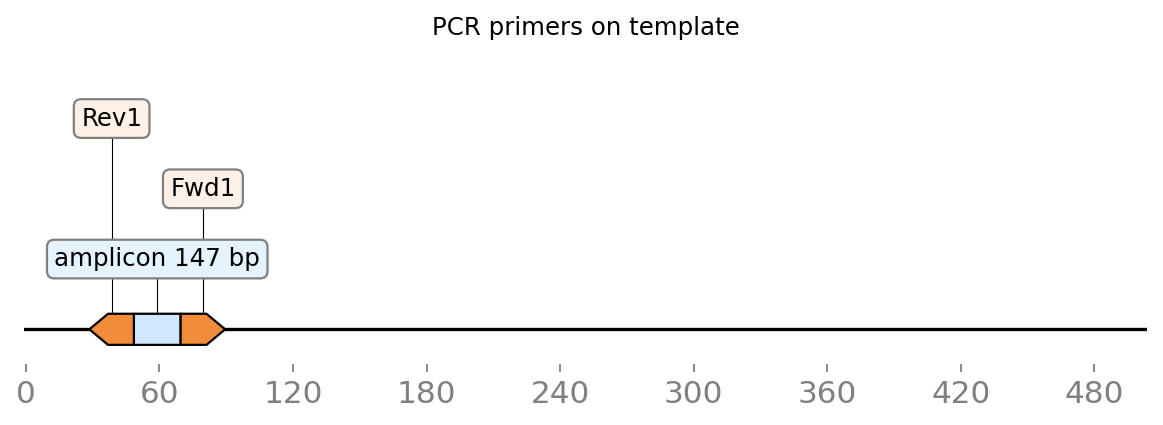

In [19]:
# design PCR primers and draw them as binding arrows on the template (amplicon highlighted)
primers = ov.synbio.design_primers(opt.sequence * 3)   # tripled so a product fits
print('cloning primers:', primers[0])
ov.synbio.view_primers(opt.sequence * 3, primers[0])
None

## 4 — The moat: A↔B coupling

Here is the feature a metabolism-only or protein-only tool can't offer: **edit an enzyme, and the metabolic network re-solves its yield.**

We start from the real *E. coli* phosphofructokinase (**PfkA**) sequence and its physiological substrate fructose-6-phosphate. `enzyme_kcat` predicts a turnover number `k_cat`; `ec_model` turns `{reaction: k_cat}` into an enzyme-capacity constraint (a lightweight GECKO); `fba` re-solves growth under that constraint.

In [20]:
PFKA = ('MIKKIGVLTSGGDAPGMNAAIRGVVRSALTEGLEVMGIYDGYLGLYEDRMVQLDRYSVSDMINRGGTFLGSARFPEFRD'
        'ENIRAVAIENLKKRGIDALVVIGGDGSYMGAMRLTEMGFPCIGLPGTIDNDIKGTDYTIGFFTALSTVVEAIDRLRDT')
F6P = 'OCC1OC(O)(COP(=O)(O)O)C(O)C1O'
k = ov.synbio.enzyme_kcat(PFKA, F6P)
print('predicted kcat(PfkA) =', round(k.kcat, 2), '/s')

[ov.synbio.enzyme_kcat] method=baseline device=cuda (NVIDIA H100 80GB HBM3, 79 GB)


predicted kcat(PfkA) = 33.28 /s


**Compare algorithms.** The `k_cat` above is the sequence-sensitive `baseline`. `method='dlkcat'` runs the **real trained DLKcat model** (Li 2022) — a substrate-graph GNN fused with a protein-sequence CNN — for a calibrated turnover number (needs the substrate SMILES).

baseline (ESM heuristic) = 33.28 /s   |   dlkcat (real trained) = 0.040 /s


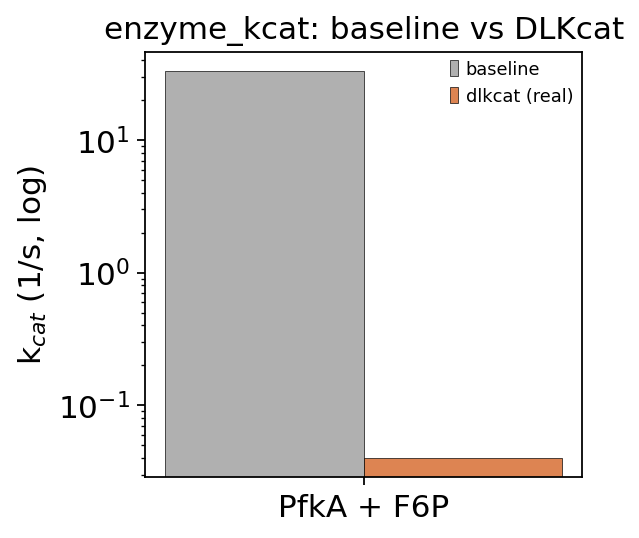

In [21]:
# k_cat: sequence baseline vs the REAL trained DLKcat model — side by side
kb = ov.synbio.enzyme_kcat(PFKA, F6P, method='baseline', verbose=False)
kd = ov.synbio.enzyme_kcat(PFKA, F6P, method='dlkcat', verbose=False)   # substrate-graph GNN + protein CNN
print(f"baseline (ESM heuristic) = {kb.kcat:.2f} /s   |   dlkcat (real trained) = {kd.kcat:.3f} /s")
ov.synbio.plot_method_comparison(['PfkA + F6P'],
    {'baseline': [kb.kcat], 'dlkcat (real)': [kd.kcat]},
    ylabel='k$_{cat}$ (1/s, log)', title='enzyme_kcat: baseline vs DLKcat', log=True)
None

In [22]:
ecm = ov.synbio.ec_model(m, {'PFK': k.kcat})
print('growth under enzyme constraint =', round(ov.synbio.fba(ecm).objective_value, 4), '/h')

growth under enzyme constraint = 0.4212 /h


**Compare formulations (side by side).** `ec_model` defaults to `method='gecko'` — the real **full-proteome** sMOMENT/GECKO, where all 69 enzymatic reactions compete for a shared protein-mass budget (so it lowers max growth, exactly as published ecModels do). `method='pool'` constrains only the listed reaction — lighter, but blind to proteome competition.

In [23]:
# same PFK kcat, two enzyme-constraint formulations — side by side
g_free  = ov.synbio.fba(m).objective_value
g_gecko = ov.synbio.fba(ov.synbio.ec_model(m, {'PFK': k.kcat}, method='gecko')).objective_value
g_pool  = ov.synbio.fba(ov.synbio.ec_model(m, {'PFK': k.kcat}, method='pool')).objective_value
print('COMPARISON — max growth /h under each formulation')
print(f"  unconstrained FBA                         : {g_free:.3f}")
print(f"  ec_model method='gecko' (full proteome)   : {g_gecko:.3f}   <- default, real sMOMENT/GECKO")
print(f"  ec_model method='pool'  (only PFK)        : {g_pool:.3f}")

COMPARISON — max growth /h under each formulation
  unconstrained FBA                         : 0.874
  ec_model method='gecko' (full proteome)   : 0.421   <- default, real sMOMENT/GECKO
  ec_model method='pool'  (only PFK)        : 0.848


Now sweep the enzyme's `k_cat` under the **same protein budget** — imagine slower or engineered-faster variants. `plot_enzyme_yield_response` builds an enzyme-constrained model at each `k_cat` and re-solves growth. A faster enzyme needs less protein per unit flux, so the capacity constraint relaxes and attainable growth rises until it plateaus at the unconstrained optimum. **That is a quantitative link from sequence → phenotype** — the ov.synbio moat, in one figure.

,kcat,growth
0,3.328,0.350191
1,6.655,0.387082
2,9.983,0.400752
3,16.638,0.412246
4,23.293,0.417334


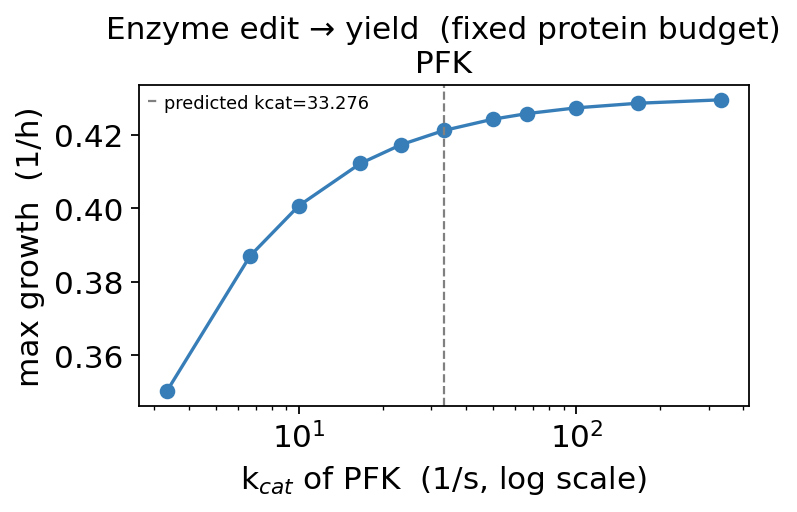

In [24]:
fig, curve = ov.synbio.plot_enzyme_yield_response(m, 'PFK', base_kcat=k.kcat)
curve.head()

## Summary

In one notebook we went from a **metabolic network** (FBA, strain design, production envelope) through **protein/enzyme design** (embeddings, saturation-scan heatmap, ESMFold structure in interactive 3D, ProteinMPNN redesign, ΔΔG) to **DNA** (codon optimization, primers) — and closed the loop with the **A↔B hinge**, where an enzyme's predicted `k_cat` reshapes the metabolic yield.

**Baseline → SOTA via `method=`.** Following the omicverse convention, every task is one function; swapping in a state-of-the-art backend is just a `method=` value (never a new function):

- `stability_ddg(..., method='thermompnn')` — real trained ThermoMPNN (calibrated ΔΔG), vs the default ProteinMPNN proxy (shown above).
- `enzyme_function(seq, method='clean')` — real CLEAN EC-number model, vs the `knn` baseline.
- `strain_design(m, target, method='optknock')` — exact StrainDesign MILP, vs the `fseof` heuristic.
- `ec_model(m, kcat, method='gecko')` — full-proteome GECKO (the default), vs `method='pool'`.
- `rbs_strength(utr, method='ostir')` — the OSTIR RBS Calculator; `reaction_dg(rxn, method='equilibrator')` for eQuilibrator.

Where to go next:

- Swap `e_coli_core` for a genome-scale model such as `iML1515`, or your own SBML.
- Feed `variant_effect` / `stability_ddg` rankings back into `enzyme_kcat` → `ec_model` to screen enzyme variants *in silico* for pathway yield.

Every function is registered under `synthetic_biology` — run `ov.list_functions(category='synthetic_biology')` to see the full surface.